In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
heteroplasmy_df = pd.read_csv('/content/drive/MyDrive/HeteroplasmyCalls.csv')

In [4]:
#Identify variant columns
variant_cols = [col for col in heteroplasmy_df.columns if col.startswith("Var_")]

In [5]:
#Create model dataframe with variants and covariates
model_df = heteroplasmy_df[
    variant_cols + ["PTB", "GAGEBRTH", "PW_AGE", "BMI", "MainHap", "population", "site"]
].copy()

#Drop variants with no variation
model_df = model_df.loc[:, model_df.nunique() > 1]

In [6]:
#Filter variant columns again after dropping
variant_cols = [col for col in model_df.columns if col.startswith("Var_")]

In [7]:
#Prepare PCA components
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Prepare variant data for PCA
X_var = model_df[variant_cols].fillna(0)
X_var_scaled = StandardScaler().fit_transform(X_var)

#Perform PCA
pca = PCA(n_components=0.80)
X_var_pca = pca.fit_transform(X_var_scaled)

print(f"PCA components retained: {pca.n_components_}")

PCA components retained: 14


In [8]:
#Create PCA column names
pca_cols = [f'mtDNA_PC{i+1}' for i in range(pca.n_components_)]

#Create DataFrame for PCA components
pca_df = pd.DataFrame(X_var_pca, columns=pca_cols)

#Combine with original data
combined_df = pd.concat([model_df.reset_index(drop=True), pca_df], axis=1)

In [9]:
#Prepare covariates (BMI, Age, Site)
#One-hot encode site variable
site_encoded = pd.get_dummies(combined_df["site"], drop_first=True, prefix="site")

#Combine all features: PCA components + BMI + Age + site dummies
X_features = pd.concat([
    combined_df[pca_cols],
    combined_df[["BMI", "PW_AGE"]],
    site_encoded
], axis=1)

#Target variable
y = combined_df["PTB"].astype(float)

In [10]:
#Define populations
south_asian_sites = ['GAPPS-Bangladesh', 'AMANHI-Pakistan', 'AMANHI-Bangladesh']
african_sites = ['AMANHI-Pemba', 'GAPPS-Zambia']

sa_df = combined_df[combined_df['site'].isin(south_asian_sites)].copy()
af_df = combined_df[combined_df['site'].isin(african_sites)].copy()

print(f"South Asian: {len(sa_df)} samples")
print(f"African: {len(af_df)} samples")

South Asian: 4718 samples
African: 3881 samples


In [11]:
def run_regression_model(X, y, model_type='linear', feature_names=None):
    """Run linear or logistic regression with FDR correction"""
    X_const = sm.add_constant(X.astype(float))

    if model_type == 'linear':
        model = sm.OLS(y.astype(float), X_const)
        result = model.fit()
    else:  # logistic
        model = sm.Logit(y.astype(float), X_const)
        result = model.fit(disp=False, maxiter=1000)

    # Calculate adjusted p-values
    results_df = pd.DataFrame({
        'feature': X_const.columns,
        'coef': result.params,
        'p_value': result.pvalues
    })

    if model_type == 'logistic':
        results_df['odds_ratio'] = np.exp(result.params)

    results_df['p_adj_fdr'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

    return results_df

mtDNA PCs analysis

SOUTH ASIAN POPULATION

In [12]:
import statsmodels.formula.api as smf
#Prepare South Asian features
sa_X_all = X_features.loc[sa_df.index].copy()

#Keep only South Asian site columns
sa_site_cols_in_data = []
for site in south_asian_sites:
    site_col = f"site_{site}"
    if site_col in sa_X_all.columns:
        sa_site_cols_in_data.append(site_col)

#Create mtDNA PCs + BMI + PW_AGE + South Asian sites
non_site_cols = [col for col in sa_X_all.columns if not col.startswith('site_')]
sa_X = sa_X_all[non_site_cols + sa_site_cols_in_data].copy()

print(f"Features included: {len(sa_X.columns)} total")
print(f"mtDNA PCs: {len([col for col in sa_X.columns if col.startswith('mtDNA_PC')])}")
print(f"Site indicators: {len(sa_site_cols_in_data)}")
print(f"Covariates: BMI, PW_AGE")



Features included: 18 total
mtDNA PCs: 14
Site indicators: 2
Covariates: BMI, PW_AGE


Preterm Birth


 PTB Logistic Regression - South Asian:
Significant (FDR<0.05): 3 features
                                     feature  odds_ratio     p_adj_fdr
const                                  const    0.023743  7.451567e-18
site_GAPPS-Bangladesh  site_GAPPS-Bangladesh    2.633762  2.534828e-08
site_AMANHI-Pakistan    site_AMANHI-Pakistan    2.503736  1.504747e-06
PTB Mixed Model - Fixed effects with FDR:
Significant: 0 features
PTB ROC-AUC: 0.536

Top 5 features for PTB prediction:
       feature  importance
14         BMI    0.097836
8    mtDNA_PC9    0.078234
5    mtDNA_PC6    0.076174
0    mtDNA_PC1    0.068534
13  mtDNA_PC14    0.065452


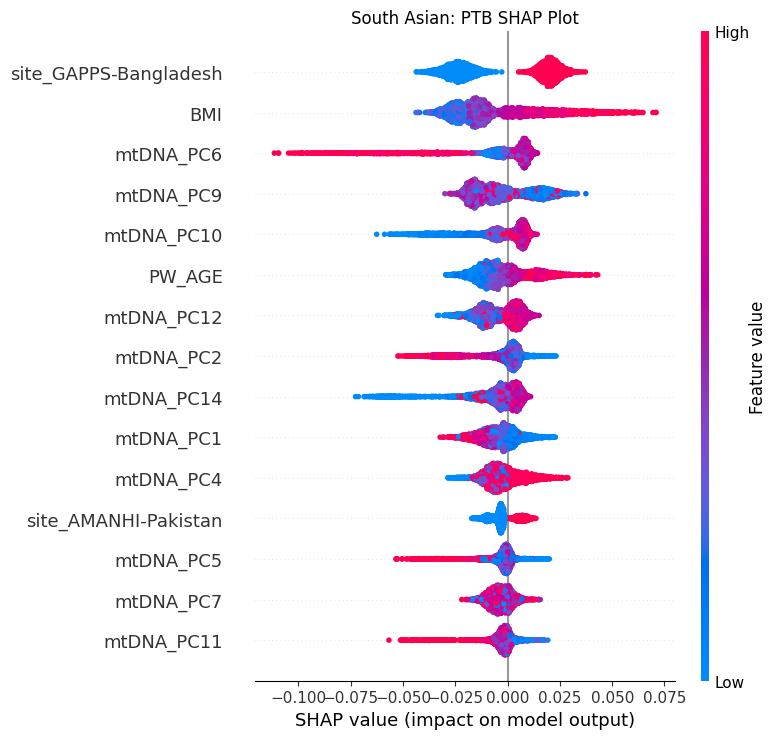

In [13]:
#PTB Logistic Regression
print("\n PTB Logistic Regression - South Asian:")
X_sa_ptb = sm.add_constant(sa_X.astype(float))
y_sa_ptb = sa_df['PTB'].astype(float)

model_ptb_sa = sm.Logit(y_sa_ptb, X_sa_ptb)
result_ptb_sa = model_ptb_sa.fit(disp=False, maxiter=1000)

results_ptb_sa = pd.DataFrame({
    'feature': X_sa_ptb.columns,
    'coef': result_ptb_sa.params,
    'p_value': result_ptb_sa.pvalues,
    'odds_ratio': np.exp(result_ptb_sa.params)
})
results_ptb_sa['p_adj_fdr'] = multipletests(results_ptb_sa['p_value'], method='fdr_bh')[1]

sig_ptb_sa = results_ptb_sa[results_ptb_sa['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant (FDR<0.05): {len(sig_ptb_sa)} features")
if len(sig_ptb_sa) > 0:
    print(sig_ptb_sa[['feature', 'odds_ratio', 'p_adj_fdr']].head(10).to_string())


#PTB Mixed Model
ptb_mixed_formula_sa = "PTB ~ " + " + ".join([col for col in sa_X.columns if col.startswith('mtDNA_PC')]) + " + BMI + PW_AGE"
mixed_ptb_sa = smf.mixedlm(ptb_mixed_formula_sa, data=sa_df, groups=sa_df["site"])
result_mixed_ptb_sa = mixed_ptb_sa.fit()

print("PTB Mixed Model - Fixed effects with FDR:")
mixed_ptb_fixed_sa = pd.DataFrame({
    'feature': result_mixed_ptb_sa.params.index,
    'coef': result_mixed_ptb_sa.params.values,
    'p_value': result_mixed_ptb_sa.pvalues.values
}).drop(index='Group Var', errors='ignore')
mixed_ptb_fixed_sa['p_adj_fdr'] = multipletests(mixed_ptb_fixed_sa['p_value'], method='fdr_bh')[1]
sig_mixed_ptb_sa = mixed_ptb_fixed_sa[mixed_ptb_fixed_sa['p_adj_fdr'] < 0.05]
print(f"Significant: {len(sig_mixed_ptb_sa)} features")

#PTB RF
rf_ptb_sa = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, class_weight='balanced')
ptb_auc_sa = cross_val_score(rf_ptb_sa, sa_X, sa_df['PTB'], cv=5, scoring='roc_auc').mean()
rf_ptb_sa.fit(sa_X, sa_df['PTB'])

print(f"PTB ROC-AUC: {ptb_auc_sa:.3f}")

#Feature importance
ptb_importance_sa = pd.DataFrame({
    'feature': sa_X.columns,
    'importance': rf_ptb_sa.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 features for PTB prediction:")
print(ptb_importance_sa.head(5).to_string())

#PTB SHAP visualization
import shap
import matplotlib.pyplot as plt
explainer_ptb_sa = shap.TreeExplainer(rf_ptb_sa)
shap_ptb_sa = explainer_ptb_sa.shap_values(sa_X)

shap_values = shap_ptb_sa[:, :, 1]
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, sa_X,

                  max_display=15,
                  show=False)
plt.title("South Asian: PTB SHAP Plot")
plt.tight_layout()
plt.show()

In [14]:
#Site differences (Bangladesh, Pakistan) were the only significant predictors of preterm birth, with odds ratios >2.5.
#Random Forest model showed minimal predictive power for PTB (AUC=0.536p)
#Site remained the most influential feature, with several mtDNA PCs contributing modestly.

Gestational Age


 GA Linear Regression - South Asian:
Significant (FDR<0.05): 3 features
                                     feature        coef     p_adj_fdr
const                                  const  276.871816  0.000000e+00
site_GAPPS-Bangladesh  site_GAPPS-Bangladesh   -2.641866  1.677790e-10
site_AMANHI-Pakistan    site_AMANHI-Pakistan   -2.428344  5.262625e-07

GA Mixed Model - Fixed effects with FDR:
Significant: 1 features
PTB ROC-AUC: 0.536
GA R²: -0.031


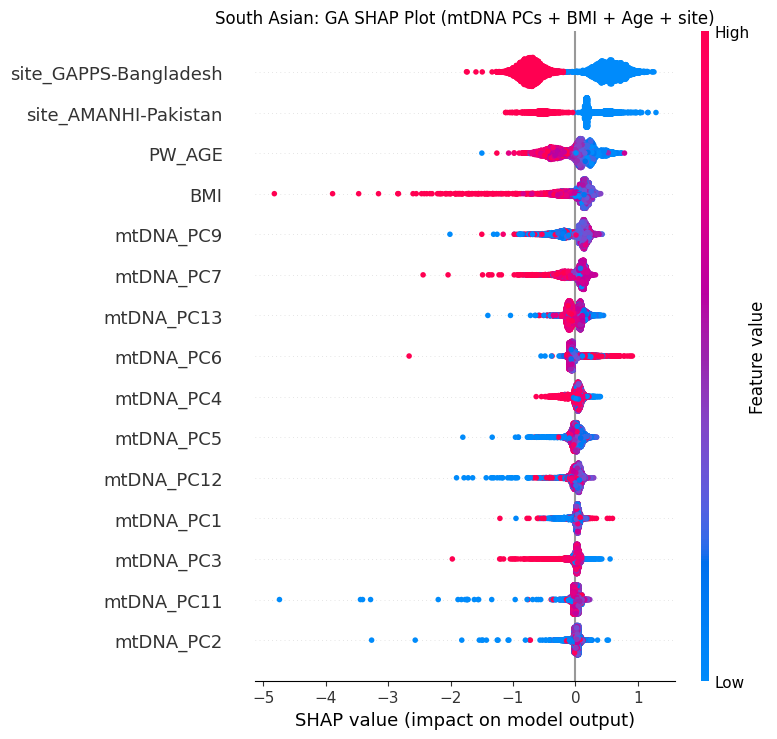

In [15]:
#GA Linear Regression
print("\n GA Linear Regression - South Asian:")
X_sa_ga = sm.add_constant(sa_X.astype(float))
y_sa_ga = sa_df['GAGEBRTH'].astype(float)

model_ga_sa = sm.OLS(y_sa_ga, X_sa_ga)
result_ga_sa = model_ga_sa.fit()

results_ga_sa = pd.DataFrame({
    'feature': X_sa_ga.columns,
    'coef': result_ga_sa.params,
    'p_value': result_ga_sa.pvalues
})
results_ga_sa['p_adj_fdr'] = multipletests(results_ga_sa['p_value'], method='fdr_bh')[1]

sig_ga_sa = results_ga_sa[results_ga_sa['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant (FDR<0.05): {len(sig_ga_sa)} features")
if len(sig_ga_sa) > 0:
    print(sig_ga_sa[['feature', 'coef', 'p_adj_fdr']].head(10).to_string())


#GA Mixed Model
ga_mixed_formula_sa = "GAGEBRTH ~ " + " + ".join([col for col in sa_X.columns if col.startswith('mtDNA_PC')]) + " + BMI + PW_AGE"
mixed_ga_sa = smf.mixedlm(ga_mixed_formula_sa, data=sa_df, groups=sa_df["site"])
result_mixed_ga_sa = mixed_ga_sa.fit()

print("\nGA Mixed Model - Fixed effects with FDR:")
mixed_ga_fixed_sa = pd.DataFrame({
    'feature': result_mixed_ga_sa.params.index,
    'coef': result_mixed_ga_sa.params.values,
    'p_value': result_mixed_ga_sa.pvalues.values
}).drop(index='Group Var', errors='ignore')
mixed_ga_fixed_sa['p_adj_fdr'] = multipletests(mixed_ga_fixed_sa['p_value'], method='fdr_bh')[1]
sig_mixed_ga_sa = mixed_ga_fixed_sa[mixed_ga_fixed_sa['p_adj_fdr'] < 0.05]
print(f"Significant: {len(sig_mixed_ga_sa)} features")

#GA RF
rf_ga_sa = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
ga_r2_sa = cross_val_score(rf_ga_sa, sa_X, sa_df['GAGEBRTH'], cv=5, scoring='r2').mean()
rf_ga_sa.fit(sa_X, sa_df['GAGEBRTH'])

print(f"PTB ROC-AUC: {ptb_auc_sa:.3f}")
print(f"GA R²: {ga_r2_sa:.3f}")

#GA SHAP visualization
explainer_ga_sa = shap.TreeExplainer(rf_ga_sa)
shap_ga_sa = explainer_ga_sa.shap_values(sa_X)

shap_values = shap_ptb_sa[:, :, 1]
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_ga_sa, sa_X,

                  max_display=15,
                  show=False)
plt.title("South Asian: GA SHAP Plot (mtDNA PCs + BMI + Age + site)")
plt.tight_layout()
plt.show()


In [16]:
#Site was the only significant predictor of gestational age, explaining most variance.
#Site dominated GA prediction, with minimal contributions from mtDNA PCs or clinical covariates.

In [17]:
#Two hurdle regression
# Heteroplasmy window
AF_LOW  = 0.01   # below this = homoplasmic reference  (non-carrier)
AF_HIGH = 0.95   # above this = homoplasmic alternate   (non-carrier)
#Only AF in [0.01, 0.95] is counted as heteroplasmic (carrier)

PTB_CUT = 259    #in days

In [18]:
#Build the SA heteroplasmy data frame
sa_variants_df = model_df.loc[sa_df.index].copy()

sa_var_cols = [c for c in sa_variants_df.columns if c.startswith("Var_")]

#Keeping only variants that have at least one SA carrier
sa_var_cols_with_carriers = [
    v for v in sa_var_cols
    if ((sa_variants_df[v] >= AF_LOW) & (sa_variants_df[v] <= AF_HIGH)).any()
]

print(f"Total Var_ columns              : {len(sa_var_cols)}")
print(f"Variants with ≥1 SA carrier     : {len(sa_var_cols_with_carriers)}")

Total Var_ columns              : 125
Variants with ≥1 SA carrier     : 125


In [19]:
#Build presence (binary) and log-AF matrices

#PRESENCE — 1 if sample is a heteroplasmic carrier, else 0
presence_sa = pd.DataFrame(
    {
        v: ((sa_variants_df[v] >= AF_LOW) & (sa_variants_df[v] <= AF_HIGH)).astype(int)
        for v in sa_var_cols_with_carriers
    },
    index=sa_variants_df.index
)

#LOG-AF — log(AF) for carriers; NaN for non-carriers
logaf_sa = pd.DataFrame(
    {
        v: np.where(
            (sa_variants_df[v] >= AF_LOW) & (sa_variants_df[v] <= AF_HIGH),
            np.log(sa_variants_df[v].clip(lower=1e-6)),
            np.nan
        )
        for v in sa_var_cols_with_carriers
    },
    index=sa_variants_df.index
)

In [20]:
#Build covariate block

site_dummies_sa = pd.get_dummies(
    sa_variants_df["site"], prefix="site", drop_first=True
).astype(float)

#Combined covariate block used in every regression
covariates_sa = pd.concat(
    [sa_variants_df[["BMI", "PW_AGE"]].astype(float), site_dummies_sa],
    axis=1
)

#Outcome
ga_sa = sa_variants_df["GAGEBRTH"].astype(float)

print("Covariate columns :", list(covariates_sa.columns))
print(f"N (SA)            : {len(ga_sa)}")

Covariate columns : ['BMI', 'PW_AGE', 'site_AMANHI-Pakistan', 'site_GAPPS-Bangladesh']
N (SA)            : 4718


In [21]:
#Run the two-part hurdle model
# For each variant:
#   Part 1 — PRESENCE model
#             OLS: GA ~ carrier_status + BMI + PW_AGE + site_*
#             (all samples; carrier_status is 0/1)
#
#   Part 2 — DOSE / LOG model
#             OLS: GA ~ log(AF) + BMI + PW_AGE + site_*
#             (carriers only; requires ≥ 5 carriers for a stable fit)

MIN_CARRIERS = 5      #minimum carrier count for the dose model

results_present = []
results_log     = []

for v in sa_var_cols_with_carriers:

    pres_v     = presence_sa[v]
    n_carriers = int(pres_v.sum())
    prev_het   = float(pres_v.mean())

    #PART 1: Presence Model
    try:
        X_pres = sm.add_constant(
            pd.concat([pres_v.rename("presence"), covariates_sa], axis=1)
        ).astype(float)
        fit_pres  = sm.OLS(ga_sa, X_pres).fit()
        coef_p    = fit_pres.params["presence"]
        pval_p    = fit_pres.pvalues["presence"]
    except Exception:
        coef_p, pval_p = np.nan, np.nan

    results_present.append({
        "variant"       : v,
        "coef_present"  : coef_p,
        "p_present"     : pval_p,
        "n_carriers"    : n_carriers,
        "prevalence_het": prev_het,
        "n_used"        : len(ga_sa)
    })

    #PART 2: Dose / log model (carriers only)
    if n_carriers < MIN_CARRIERS:
        results_log.append({
            "variant"       : v,
            "coef_log"      : np.nan,
            "p_log"         : np.nan,
            "n_carriers"    : n_carriers,
            "prevalence_het": prev_het,
            "n_used"        : n_carriers
        })
        continue

    carrier_idx  = pres_v[pres_v == 1].index
    logaf_v      = logaf_sa.loc[carrier_idx, v]
    ga_carriers  = ga_sa.loc[carrier_idx]
    cov_carriers = covariates_sa.loc[carrier_idx]

    try:
        X_log    = sm.add_constant(
            pd.concat([logaf_v.rename("log_af"), cov_carriers], axis=1)
        ).astype(float)
        fit_log  = sm.OLS(ga_carriers, X_log).fit()
        coef_l   = fit_log.params["log_af"]
        pval_l   = fit_log.pvalues["log_af"]
    except Exception:
        coef_l, pval_l = np.nan, np.nan

    results_log.append({
        "variant"       : v,
        "coef_log"      : coef_l,
        "p_log"         : pval_l,
        "n_carriers"    : n_carriers,
        "prevalence_het": prev_het,
        "n_used"        : n_carriers
    })

df_present_sa = pd.DataFrame(results_present).dropna(subset=["p_present"])
df_log_sa     = pd.DataFrame(results_log).dropna(subset=["p_log"])

SOUTH ASIAN — Heteroplasmy Hurdle Model: GA Results
Variants attempted               : 125
Successful fits                  : 125
Significant (presence) FDR<0.05  : 1
Significant (dose/log) FDR<0.05  : 0

Top presence hits:
      variant  coef_present  p_present  fdr_present  n_carriers  prevalence_het  n_used
Var_5147_GtoA      -9.85811   0.000186     0.023225          16        0.003391    4718

Top dose/log hits:
  None significant after FDR correction.


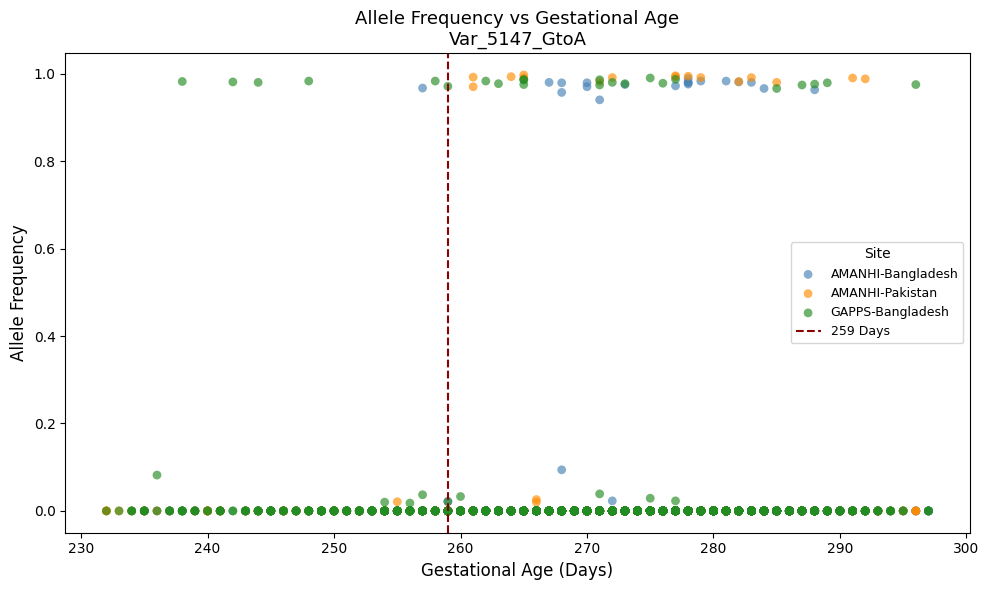

In [22]:
#FDR correction
df_present_sa["fdr_present"] = multipletests(
    df_present_sa["p_present"], method="fdr_bh"
)[1]

df_log_sa["fdr_log"] = multipletests(
    df_log_sa["p_log"], method="fdr_bh"
)[1]

#Summary
sig_present_sa = df_present_sa[df_present_sa["fdr_present"] < 0.05].sort_values("fdr_present")
sig_log_sa     = df_log_sa    [df_log_sa    ["fdr_log"]     < 0.05].sort_values("fdr_log")

print("=" * 60)
print("SOUTH ASIAN — Heteroplasmy Hurdle Model: GA Results")
print("=" * 60)
print(f"Variants attempted               : {len(sa_var_cols_with_carriers)}")
print(f"Successful fits                  : {len(df_present_sa)}")
print(f"Significant (presence) FDR<0.05  : {len(sig_present_sa)}")
print(f"Significant (dose/log) FDR<0.05  : {len(sig_log_sa)}")

print("\nTop presence hits:")
if len(sig_present_sa):
    print(sig_present_sa[["variant", "coef_present", "p_present",
                           "fdr_present", "n_carriers",
                           "prevalence_het", "n_used"]].to_string(index=False))
else:
    print("  None significant after FDR correction.")

print("\nTop dose/log hits:")
if len(sig_log_sa):
    print(sig_log_sa[["variant", "coef_log", "p_log",
                       "fdr_log", "n_carriers",
                       "prevalence_het", "n_used"]].to_string(index=False))
else:
    print("  None significant after FDR correction.")

#Scatter plots for significant hits

sa_sites_sorted = sorted(sa_variants_df["site"].unique())
palette = ["steelblue", "darkorange", "forestgreen"]
site_color = dict(zip(sa_sites_sorted, palette))

sig_to_plot = (
    set(sig_present_sa["variant"]) | set(sig_log_sa["variant"])
)

if not sig_to_plot:
    print("\nNo FDR-significant hits — plotting top 3 nominal presence hits for exploration.")
    top3 = df_present_sa.nsmallest(3, "p_present")["variant"].tolist()
    sig_to_plot = set(top3)

for v in sorted(sig_to_plot):

    af_arr   = sa_variants_df[v].values
    ga_arr   = ga_sa.values
    site_arr = sa_variants_df["site"].values

    fig, ax = plt.subplots(figsize=(10, 6))

    for site_name in sa_sites_sorted:
        mask = site_arr == site_name
        ax.scatter(
            ga_arr[mask], af_arr[mask],
            label=site_name,
            color=site_color.get(site_name, "grey"),
            alpha=0.65, s=40, edgecolors="none"
        )

    ax.axvline(PTB_CUT, color="darkred", linestyle="--",
               linewidth=1.5, label=f"{PTB_CUT} Days")

    ax.set_xlabel("Gestational Age (Days)", fontsize=12)
    ax.set_ylabel("Allele Frequency", fontsize=12)
    ax.set_title(f"Allele Frequency vs Gestational Age\n{v}", fontsize=13)
    ax.legend(title="Site", fontsize=9)
    plt.tight_layout()
    plt.show()

In [23]:
#Check site distribution of Var_5147_GtoA carriers
carrier_mask = (sa_variants_df["Var_5147_GtoA"] >= 0.01) & (sa_variants_df["Var_5147_GtoA"] <= 0.95)
print(sa_variants_df[carrier_mask]["site"].value_counts())
print(f"\nMean GA in carriers  : {sa_variants_df.loc[carrier_mask, 'GAGEBRTH'].mean():.1f} days")
print(f"Mean GA in non-carriers: {sa_variants_df.loc[~carrier_mask, 'GAGEBRTH'].mean():.1f} days")


site
GAPPS-Bangladesh     9
AMANHI-Bangladesh    4
AMANHI-Pakistan      3
Name: count, dtype: int64

Mean GA in carriers  : 262.6 days
Mean GA in non-carriers: 272.5 days


AFRICAN POPULATION

In [24]:
#Prepare African features
af_X_all = X_features.loc[af_df.index].copy()

af_site_cols_in_data = []
for site in african_sites:
    site_col = f"site_{site}"
    if site_col in af_X_all.columns:
        af_site_cols_in_data.append(site_col)

#Create mtDNA PCs + BMI + PW_AGE + African sites
af_X = af_X_all[non_site_cols + af_site_cols_in_data].copy()

print(f"Features included: {len(af_X.columns)} total")
print(f"mtDNA PCs: {len([col for col in af_X.columns if col.startswith('mtDNA_PC')])}")
print(f"Site indicators: {len(af_site_cols_in_data)}")
print(f"Covariates: BMI, PW_AGE")

Features included: 18 total
mtDNA PCs: 14
Site indicators: 2
Covariates: BMI, PW_AGE


Preterm Birth


 PTB Logistic Regression - African:
Significant (FDR<0.05): 0 features
PTB Mixed Model - Fixed effects with FDR:
Significant: 0 features
PTB ROC-AUC: 0.501

Top 5 features for PTB prediction:
       feature  importance
14         BMI    0.084482
0    mtDNA_PC1    0.074643
10  mtDNA_PC11    0.074581
11  mtDNA_PC12    0.066326
5    mtDNA_PC6    0.065783


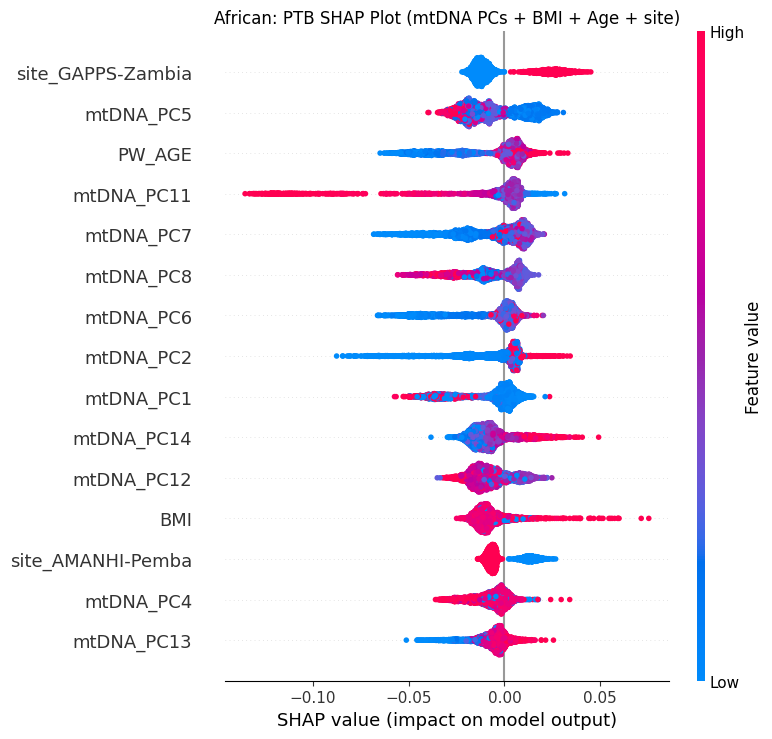

In [25]:
#PTB Logistic Regression
print("\n PTB Logistic Regression - African:")
X_af_ptb = sm.add_constant(af_X.astype(float))
y_af_ptb = af_df['PTB'].astype(float)

model_ptb_af = sm.Logit(y_af_ptb, X_af_ptb)
result_ptb_af = model_ptb_af.fit(disp=False, maxiter=1000)

results_ptb_af = pd.DataFrame({
    'feature': X_af_ptb.columns,
    'coef': result_ptb_af.params,
    'p_value': result_ptb_af.pvalues,
    'odds_ratio': np.exp(result_ptb_af.params)
})
results_ptb_af['p_adj_fdr'] = multipletests(results_ptb_af['p_value'], method='fdr_bh')[1]

sig_ptb_af = results_ptb_af[results_ptb_af['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant (FDR<0.05): {len(sig_ptb_af)} features")
if len(sig_ptb_af) > 0:
    print(sig_ptb_af[['feature', 'odds_ratio', 'p_adj_fdr']].head(10).to_string())

#PTB Mixed Model
ptb_mixed_formula_af = "PTB ~ " + " + ".join([col for col in af_X.columns if col.startswith('mtDNA_PC')]) + " + BMI + PW_AGE"
mixed_ptb_af = smf.mixedlm(ptb_mixed_formula_af, data=af_df, groups=af_df["site"])
result_mixed_ptb_af = mixed_ptb_af.fit()

print("PTB Mixed Model - Fixed effects with FDR:")
mixed_ptb_fixed_af = pd.DataFrame({
    'feature': result_mixed_ptb_af.params.index,
    'coef': result_mixed_ptb_af.params.values,
    'p_value': result_mixed_ptb_af.pvalues.values
}).drop(index='Group Var', errors='ignore')
mixed_ptb_fixed_af['p_adj_fdr'] = multipletests(mixed_ptb_fixed_af['p_value'], method='fdr_bh')[1]
sig_mixed_ptb_af = mixed_ptb_fixed_af[mixed_ptb_fixed_af['p_adj_fdr'] < 0.05]
print(f"Significant: {len(sig_mixed_ptb_af)} features")

#PTB RF
rf_ptb_af = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, class_weight='balanced')
ptb_auc_af = cross_val_score(rf_ptb_af, af_X, af_df['PTB'], cv=5, scoring='roc_auc').mean()
rf_ptb_af.fit(af_X, af_df['PTB'])

print(f"PTB ROC-AUC: {ptb_auc_af:.3f}")

#Feature importance
ptb_importance_af = pd.DataFrame({
    'feature': af_X.columns,
    'importance': rf_ptb_af.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 features for PTB prediction:")
print(ptb_importance_af.head(5).to_string())

#PTB SHAP visualization
explainer_ptb_af = shap.TreeExplainer(rf_ptb_af)
shap_ptb_af = explainer_ptb_af.shap_values(af_X)

shap_values = shap_ptb_af[:, :, 1]
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, af_X,

                 max_display=15,
                 show=False)
plt.title("African: PTB SHAP Plot (mtDNA PCs + BMI + Age + site)")
plt.tight_layout()
plt.show()

In [26]:
#No significant associations found with mtDNA PCs, clinical variables, or site for preterm birth prediction.
#Model performed at chance level (AUC=0.501), indicating no meaningful prediction.
#Site (Zambia) was most important, but mtDNA_PC5 showed notable contribution.

Gestational Age


 GA Linear Regression - African:
Significant (FDR<0.05): 3 features
                             feature        coef  p_adj_fdr
const                          const  183.185141        0.0
site_AMANHI-Pemba  site_AMANHI-Pemba   92.024405        0.0
site_GAPPS-Zambia  site_GAPPS-Zambia   91.160736        0.0

GA Mixed Model - Fixed effects with FDR:
Significant: 0 features
GA R²: -0.020


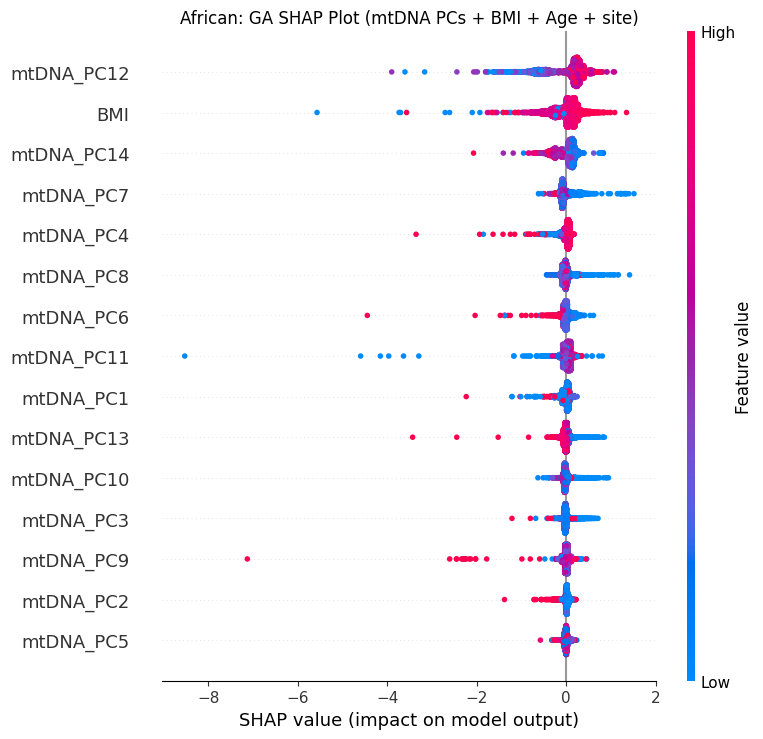

In [27]:
#GA Linear Regression
print("\n GA Linear Regression - African:")
X_af_ga = sm.add_constant(af_X.astype(float))
y_af_ga = af_df['GAGEBRTH'].astype(float)

model_ga_af = sm.OLS(y_af_ga, X_af_ga)
result_ga_af = model_ga_af.fit()

results_ga_af = pd.DataFrame({
    'feature': X_af_ga.columns,
    'coef': result_ga_af.params,
    'p_value': result_ga_af.pvalues
})
results_ga_af['p_adj_fdr'] = multipletests(results_ga_af['p_value'], method='fdr_bh')[1]

sig_ga_af = results_ga_af[results_ga_af['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant (FDR<0.05): {len(sig_ga_af)} features")
if len(sig_ga_af) > 0:
    print(sig_ga_af[['feature', 'coef', 'p_adj_fdr']].head(10).to_string())


#GA Mixed Model
ga_mixed_formula_af = "GAGEBRTH ~ " + " + ".join([col for col in af_X.columns if col.startswith('mtDNA_PC')]) + " + BMI + PW_AGE"
mixed_ga_af = smf.mixedlm(ga_mixed_formula_af, data=af_df, groups=af_df["site"])
result_mixed_ga_af = mixed_ga_af.fit()


print("\nGA Mixed Model - Fixed effects with FDR:")
mixed_ga_fixed_af = pd.DataFrame({
    'feature': result_mixed_ga_af.params.index,
    'coef': result_mixed_ga_af.params.values,
    'p_value': result_mixed_ga_af.pvalues.values
}).drop(index='Group Var', errors='ignore')
mixed_ga_fixed_af['p_adj_fdr'] = multipletests(mixed_ga_fixed_af['p_value'], method='fdr_bh')[1]
sig_mixed_ga_af = mixed_ga_fixed_af[mixed_ga_fixed_af['p_adj_fdr'] < 0.05]
print(f"Significant: {len(sig_mixed_ga_af)} features")


#GA RF
rf_ga_af = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
ga_r2_af = cross_val_score(rf_ga_af, af_X, af_df['GAGEBRTH'], cv=5, scoring='r2').mean()
rf_ga_af.fit(af_X, af_df['GAGEBRTH'])

print(f"GA R²: {ga_r2_af:.3f}")

#GA SHAP visualization
explainer_ga_af = shap.TreeExplainer(rf_ga_af)
shap_ga_af = explainer_ga_af.shap_values(af_X)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_ga_af, af_X,

                  max_display=15,
                  show=False)
plt.title("African: GA SHAP Plot (mtDNA PCs + BMI + Age + site)")
plt.tight_layout()
plt.show()

In [28]:
#Site differences (Pemba, Zambia) overwhelmingly predicted gestational age with extremely large coefficients.
# mtDNA_PC12 was the strongest mtDNA predictor, but BMI and site had comparable influence.

In [29]:
#THUS,
#South Asian mtDNA patterns show modest, non-significant links to PTB/GA risk, heavily overshadowed by strong site differences.
#African mtDNA shows minimal association with PTB/GA; predictive models perform at chance level, with site being the dominant factor.

ALL VARIANT ANALYSIS


SOUTH ASIAN POPULATION

In [30]:
#Filter South Asian data
sa_variants_df = model_df.loc[sa_df.index].copy()
sa_variants = [col for col in sa_variants_df.columns if col.startswith("Var_")]

#Prepare features for South Asian
X_sa_variants = pd.concat([
    sa_variants_df[sa_variants].fillna(0),
    sa_variants_df[["BMI", "PW_AGE"]],
    pd.get_dummies(sa_variants_df["site"], drop_first=True, prefix="site")
], axis=1)

y_sa_ptb = sa_variants_df["PTB"].astype(float)
#Scale features
scaler_sa = StandardScaler()
X_sa_scaled = scaler_sa.fit_transform(X_sa_variants)



Preterm Birth

In [31]:
#PTB logistic regression
#Use regularized logistic regression
logreg_sa = LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                                max_iter=1000, class_weight='balanced', random_state=42)
logreg_sa.fit(X_sa_scaled, y_sa_ptb)

#Get p-values
from sklearn.utils import resample
from scipy import stats

#Bootstrap for p-values
n_bootstraps = 100
coefs_boot = np.zeros((n_bootstraps, X_sa_scaled.shape[1]))

for i in range(n_bootstraps):
    X_resampled, y_resampled = resample(X_sa_scaled, y_sa_ptb, random_state=i)
    model_temp = LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                                    max_iter=1000, class_weight='balanced')
    model_temp.fit(X_resampled, y_resampled)
    coefs_boot[i, :] = model_temp.coef_[0]

#Calculate p-values (two-tailed)
coef_mean = np.mean(coefs_boot, axis=0)
coef_std = np.std(coefs_boot, axis=0)
z_scores = coef_mean / (coef_std + 1e-10)
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

results_sa_ptb = pd.DataFrame({
    'feature': X_sa_variants.columns,
    'coef': logreg_sa.coef_[0],
    'p_value': p_values
})

#FDR correction
results_sa_ptb['p_adj_fdr'] = multipletests(results_sa_ptb['p_value'], method='fdr_bh')[1]

#Filter for variants only
variant_results_sa = results_sa_ptb[results_sa_ptb['feature'].str.startswith('Var_')]
sig_variants_sa = variant_results_sa[variant_results_sa['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')

print(f"Total variants tested: {len(variant_results_sa)}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_sa)}")
if len(sig_variants_sa) > 0:
    print("\nTop 5 significant variants:")
    print(sig_variants_sa[['feature', 'coef', 'p_adj_fdr']].head().to_string())
else:
    print("No significant variants found after FDR correction.")

Total variants tested: 125
Significant variants (FDR < 0.05): 7

Top 5 significant variants:
           feature      coef     p_adj_fdr
74  Var_10819_AtoG -0.245142  2.230715e-08
55   Var_8566_AtoG -1.572738  4.944309e-06
32   Var_3516_CtoA -1.096725  3.669216e-05
90  Var_13276_AtoG -0.795890  4.000864e-03
31   Var_2885_TtoC -1.192927  4.576836e-03


In [32]:
#Seven mtDNA variants were significantly associated with preterm birth risk after FDR correction, with Var_10819_AtoG showing the strongest negative association.

In [33]:
#PTB Mixed model
from statsmodels.regression.mixed_linear_model import MixedLM

variants_list_sa = [col for col in X_sa_variants.columns if col.startswith('Var_')]
formula_sa = "PTB ~ " + " + ".join(variants_list_sa) + " + BMI + PW_AGE"

#Fit mixed model
mixed_sa = MixedLM.from_formula(formula_sa, data=sa_variants_df, groups=sa_variants_df["site"])
result_mixed_sa = mixed_sa.fit()

#Extract fixed effects results
fixed_effects_sa = pd.DataFrame({
    'feature': result_mixed_sa.params.index[:-1],
    'coef': result_mixed_sa.params.values[:-1],
    'p_value': result_mixed_sa.pvalues.values[:-1]
})

#Apply FDR correction only to variants
variant_mask_sa = fixed_effects_sa['feature'].str.startswith('Var_')
fixed_effects_sa.loc[variant_mask_sa, 'p_adj_fdr'] = multipletests(
    fixed_effects_sa.loc[variant_mask_sa, 'p_value'], method='fdr_bh'
)[1]

#For non-variants (BMI, PW_AGE)
fixed_effects_sa.loc[~variant_mask_sa, 'p_adj_fdr'] = fixed_effects_sa.loc[~variant_mask_sa, 'p_value']

#Filter significant variants
sig_variants_mixed_sa = fixed_effects_sa[
    fixed_effects_sa['feature'].str.startswith('Var_') &
    (fixed_effects_sa['p_adj_fdr'] < 0.05)
].sort_values('p_adj_fdr')

print(f"Total variants tested: {len(variants_list_sa)}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_mixed_sa)}")
if len(sig_variants_mixed_sa) > 0:
    print("\nSignificant variants:")
    print(sig_variants_mixed_sa[['feature', 'coef', 'p_adj_fdr']].head().to_string())

Total variants tested: 125
Significant variants (FDR < 0.05): 0


In [34]:
#No individual mtDNA variants remained significantly associated with PTB after accounting for site random effects and FDR correction.

In [35]:
#PTB RF
#Prepare features for Random Forest
X_sa_rf = X_sa_variants.copy()
y_sa_rf = y_sa_ptb.copy()

#Train Random Forest with balanced class weights
rf_sa = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#Cross-validated AUC
cv_scores_sa = cross_val_score(rf_sa, X_sa_rf, y_sa_rf,
                               cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Cross-validated AUC: {cv_scores_sa.mean():.3f} (±{cv_scores_sa.std():.3f})")

#Fit the data for feature importance
rf_sa.fit(X_sa_rf, y_sa_rf)

importance_sa = pd.DataFrame({
    'feature': X_sa_rf.columns,
    'importance': rf_sa.feature_importances_
})

#Separate variants and covariates
variant_importance_sa = importance_sa[importance_sa['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)
covariate_importance_sa = importance_sa[~importance_sa['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)

print(f"\nTop 5 mtDNA variants by importance:")
print(variant_importance_sa.head(5).to_string())
print(f"\nCovariate importance:")
print(covariate_importance_sa.head(5).to_string())

Cross-validated AUC: 0.464 (±0.069)

Top 5 mtDNA variants by importance:
           feature  importance
0      Var_73_AtoG    0.039451
28   Var_2706_AtoG    0.029274
89  Var_13105_AtoG    0.025189
14    Var_489_TtoC    0.023641
75  Var_10873_TtoC    0.023268

Covariate importance:
                   feature  importance
125                    BMI    0.072247
126                 PW_AGE    0.042315
128  site_GAPPS-Bangladesh    0.031846
127   site_AMANHI-Pakistan    0.018020


In [36]:
#Model showed poor predictive performance (AUC=0.464) with BMI as the strongest predictor and Var_73_AtoG as the most important mtDNA variant.

Gestational Age

In [37]:
#Prepare target variable
y_sa_ga = sa_variants_df["GAGEBRTH"].astype(float)

#Add constant and fit OLS
X_sa_const = sm.add_constant(X_sa_variants.astype(float))
model_sa_ga = sm.OLS(y_sa_ga, X_sa_const)
result_sa_ga = model_sa_ga.fit()

results_sa_ga = pd.DataFrame({
    'feature': X_sa_const.columns,
    'coef': result_sa_ga.params,
    'p_value': result_sa_ga.pvalues
})

#FDR correction only for variants
variant_mask_sa = results_sa_ga['feature'].str.startswith('Var_')
results_sa_ga.loc[variant_mask_sa, 'p_adj_fdr'] = multipletests(
    results_sa_ga.loc[variant_mask_sa, 'p_value'], method='fdr_bh'
)[1]
results_sa_ga.loc[~variant_mask_sa, 'p_adj_fdr'] = results_sa_ga.loc[~variant_mask_sa, 'p_value']

#Filter significant variants
sig_variants_sa_ga = results_sa_ga[
    results_sa_ga['feature'].str.startswith('Var_') &
    (results_sa_ga['p_adj_fdr'] < 0.05)
].sort_values('p_adj_fdr')

print(f"Total variants tested: {len([col for col in X_sa_variants.columns if col.startswith('Var_')])}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_sa_ga)}")
if len(sig_variants_sa_ga) > 0:
    print("\nTop 5 significant variants:")
    print(sig_variants_sa_ga[['feature', 'coef', 'p_adj_fdr']].head().to_string())

Total variants tested: 125
Significant variants (FDR < 0.05): 0


In [38]:
#No individual mtDNA variants were significantly associated with gestational age after FDR correction.

In [39]:
#GA mixed model
formula_sa_ga = "GAGEBRTH ~ " + " + ".join(variants_list_sa) + " + BMI + PW_AGE"

#Fit mixed model for GA
mixed_sa_ga = MixedLM.from_formula(formula_sa_ga, data=sa_variants_df, groups=sa_variants_df["site"])
result_mixed_sa_ga = mixed_sa_ga.fit()

#Extract fixed effects results
fixed_effects_sa_ga = pd.DataFrame({
    'feature': result_mixed_sa_ga.params.index[:-1],
    'coef': result_mixed_sa_ga.params.values[:-1],
    'p_value': result_mixed_sa_ga.pvalues.values[:-1]
})

#Apply FDR correction only to variants
variant_mask_sa_ga = fixed_effects_sa_ga['feature'].str.startswith('Var_')
fixed_effects_sa_ga.loc[variant_mask_sa_ga, 'p_adj_fdr'] = multipletests(
    fixed_effects_sa_ga.loc[variant_mask_sa_ga, 'p_value'], method='fdr_bh'
)[1]
fixed_effects_sa_ga.loc[~variant_mask_sa_ga, 'p_adj_fdr'] = fixed_effects_sa_ga.loc[~variant_mask_sa_ga, 'p_value']

#Filter significant variants
sig_variants_mixed_sa_ga = fixed_effects_sa_ga[
    fixed_effects_sa_ga['feature'].str.startswith('Var_') &
    (fixed_effects_sa_ga['p_adj_fdr'] < 0.05)
].sort_values('p_adj_fdr')

print(f"Total variants tested: {len(variants_list_sa)}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_mixed_sa_ga)}")
if len(sig_variants_mixed_sa_ga) > 0:
    print("\nSignificant variants:")
    print(sig_variants_mixed_sa_ga[['feature', 'coef', 'p_adj_fdr']].head().to_string())

Total variants tested: 125
Significant variants (FDR < 0.05): 0


In [40]:
#GA RF
#Train Random Forest for GA prediction
rf_sa_ga = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

#Cross-validated R²
cv_scores_sa_ga = cross_val_score(rf_sa_ga, X_sa_rf, y_sa_ga,
                                 cv=5, scoring='r2', n_jobs=-1)
print(f"Cross-validated R²: {cv_scores_sa_ga.mean():.3f} (±{cv_scores_sa_ga.std():.3f})")

#Fit data for feature importance
rf_sa_ga.fit(X_sa_rf, y_sa_ga)

#Get feature importance
importance_sa_ga = pd.DataFrame({
    'feature': X_sa_rf.columns,
    'importance': rf_sa_ga.feature_importances_
})

#Separate variants and covariates
variant_importance_sa_ga = importance_sa_ga[importance_sa_ga['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)
covariate_importance_sa_ga = importance_sa_ga[~importance_sa_ga['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)

print(f"\nTop 5 mtDNA variants by importance:")
print(variant_importance_sa_ga.head(5).to_string())
print(f"\nCovariate importance:")
print(covariate_importance_sa_ga.head(5).to_string())

Cross-validated R²: -0.039 (±0.032)

Top 5 mtDNA variants by importance:
          feature  importance
37  Var_5147_GtoA    0.028254
17   Var_750_AtoG    0.026782
0     Var_73_AtoG    0.026709
14   Var_489_TtoC    0.025688
12  Var_310_TtoTC    0.023607

Covariate importance:
                   feature  importance
125                    BMI    0.096050
126                 PW_AGE    0.056267
128  site_GAPPS-Bangladesh    0.054059
127   site_AMANHI-Pakistan    0.052489


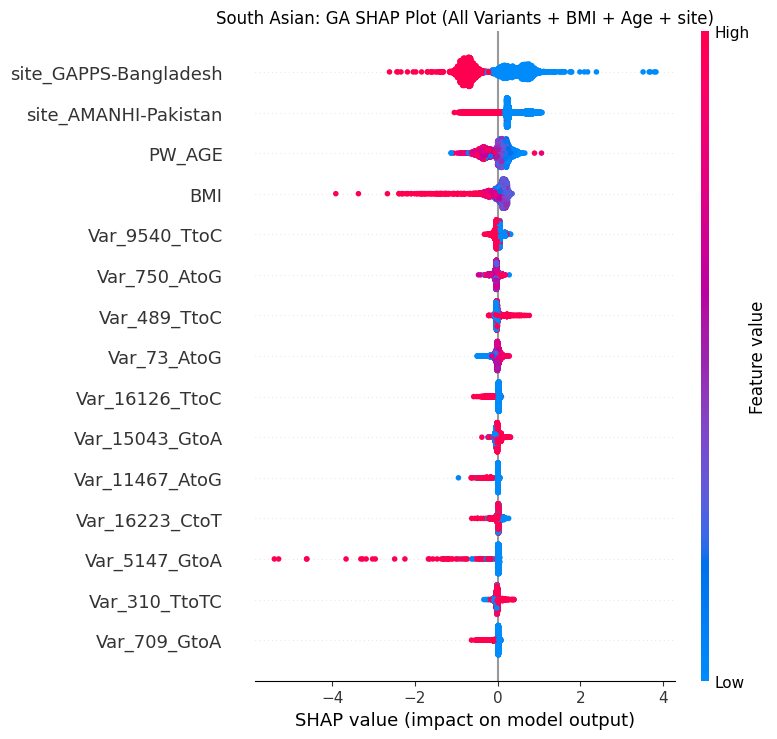

In [41]:
#GA SHAP visualization
#Create SHAP explainer
explainer_sa_ga = shap.TreeExplainer(rf_sa_ga)
shap_values_sa_ga = explainer_sa_ga.shap_values(X_sa_rf)

#Summary plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_sa_ga, X_sa_rf,
                  max_display=15,
                  show=False)
plt.title("South Asian: GA SHAP Plot (All Variants + BMI + Age + site)")
plt.tight_layout()
plt.show()

AFRICAN POPULATION

In [42]:
#Filter African data
af_variants_df = model_df.loc[af_df.index].copy()
af_variants = [col for col in af_variants_df.columns if col.startswith("Var_")]

#Prepare features for African
X_af_variants = pd.concat([
    af_variants_df[af_variants].fillna(0),
    af_variants_df[["BMI", "PW_AGE"]],
    pd.get_dummies(af_variants_df["site"], drop_first=True, prefix="site")
], axis=1)

y_af_ptb = af_variants_df["PTB"].astype(float)

#Scale features
scaler_af = StandardScaler()
X_af_scaled = scaler_af.fit_transform(X_af_variants)


Preterm Birth

In [43]:
#Use regularized logistic regression
logreg_af = LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                                max_iter=1000, class_weight='balanced', random_state=42)
logreg_af.fit(X_af_scaled, y_af_ptb)

#Bootstrap for p-values
coefs_boot_af = np.zeros((n_bootstraps, X_af_scaled.shape[1]))

for i in range(n_bootstraps):
    X_resampled, y_resampled = resample(X_af_scaled, y_af_ptb, random_state=i+1000)
    model_temp = LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                                    max_iter=1000, class_weight='balanced')
    model_temp.fit(X_resampled, y_resampled)
    coefs_boot_af[i, :] = model_temp.coef_[0]

#Calculate p-values
coef_mean_af = np.mean(coefs_boot_af, axis=0)
coef_std_af = np.std(coefs_boot_af, axis=0)
z_scores_af = coef_mean_af / (coef_std_af + 1e-10)
p_values_af = 2 * (1 - stats.norm.cdf(np.abs(z_scores_af)))

results_af_ptb = pd.DataFrame({
    'feature': X_af_variants.columns,
    'coef': logreg_af.coef_[0],
    'p_value': p_values_af
})

#FDR correction
results_af_ptb['p_adj_fdr'] = multipletests(results_af_ptb['p_value'], method='fdr_bh')[1]

#Filter for variants only
variant_results_af = results_af_ptb[results_af_ptb['feature'].str.startswith('Var_')]
sig_variants_af = variant_results_af[variant_results_af['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')

print(f"Total variants tested: {len(variant_results_af)}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_af)}")
if len(sig_variants_af) > 0:
    print("\nTop 5 significant variants:")
    print(sig_variants_af[['feature', 'coef', 'p_adj_fdr']].head().to_string())
else:
    print("No significant variants found after FDR correction.")

Total variants tested: 125
Significant variants (FDR < 0.05): 2

Top 5 significant variants:
          feature      coef  p_adj_fdr
13   Var_482_TtoC -0.417851   0.000374
56  Var_8618_TtoC  1.202568   0.003477


In [44]:
#Only two mtDNA variants showed significant associations with preterm birth, with Var_482_TtoC decreasing risk and Var_8618_TtoC increasing risk.

In [45]:
#PTB Mixed model
variants_list_af = [col for col in X_af_variants.columns if col.startswith('Var_')]
formula_af = "PTB ~ " + " + ".join(variants_list_af) + " + BMI + PW_AGE"

#Fit mixed model
mixed_af = MixedLM.from_formula(formula_af, data=af_variants_df, groups=af_variants_df["site"])
result_mixed_af = mixed_af.fit()

#Extract fixed effects results
fixed_effects_af = pd.DataFrame({
    'feature': result_mixed_af.params.index[:-1],
    'coef': result_mixed_af.params.values[:-1],
    'p_value': result_mixed_af.pvalues.values[:-1]
})

#Apply FDR correction only to variants
variant_mask_af = fixed_effects_af['feature'].str.startswith('Var_')
fixed_effects_af.loc[variant_mask_af, 'p_adj_fdr'] = multipletests(
    fixed_effects_af.loc[variant_mask_af, 'p_value'], method='fdr_bh'
)[1]

#For non-variants (BMI, PW_AGE)
fixed_effects_af.loc[~variant_mask_af, 'p_adj_fdr'] = fixed_effects_af.loc[~variant_mask_af, 'p_value']

#Filter significant variants
sig_variants_mixed_af = fixed_effects_af[
    fixed_effects_af['feature'].str.startswith('Var_') &
    (fixed_effects_af['p_adj_fdr'] < 0.05)
].sort_values('p_adj_fdr')

print(f"Total variants tested: {len(variants_list_af)}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_mixed_af)}")
if len(sig_variants_mixed_af) > 0:
    print("\nSignificant variants:")
    print(sig_variants_mixed_af[['feature', 'coef', 'p_adj_fdr']].head().to_string())

Total variants tested: 125
Significant variants (FDR < 0.05): 0


In [46]:
#No mtDNA variants showed significant association with PTB when modeling site as a random effect, after multiple testing correction.

In [47]:
#PTB RF
#Prepare features for Random Forest
X_af_rf = X_af_variants.copy()
y_af_rf = y_af_ptb.copy()

#Train Random Forest with balanced class weights
rf_af = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#Cross-validated AUC
cv_scores_af = cross_val_score(rf_af, X_af_rf, y_af_rf,
                               cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Cross-validated AUC: {cv_scores_af.mean():.3f} (±{cv_scores_af.std():.3f})")

#Fit data for feature importance
rf_af.fit(X_af_rf, y_af_rf)

#Get feature importance
importance_af = pd.DataFrame({
    'feature': X_af_rf.columns,
    'importance': rf_af.feature_importances_
})

#Separate variants and covariates
variant_importance_af = importance_af[importance_af['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)
covariate_importance_af = importance_af[~importance_af['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)

print(f"\nTop 5 mtDNA variants by importance:")
print(variant_importance_af.head(5).to_string())
print(f"\nCovariate importance:")
print(covariate_importance_af.head(5).to_string())

Cross-validated AUC: 0.571 (±0.039)

Top 5 mtDNA variants by importance:
            feature  importance
87   Var_12705_CtoT    0.037131
17     Var_750_AtoG    0.027353
75   Var_10873_TtoC    0.023496
62    Var_9540_TtoC    0.022429
116  Var_16278_CtoT    0.021385

Covariate importance:
               feature  importance
125                BMI    0.034834
126             PW_AGE    0.030463
127  site_GAPPS-Zambia    0.015516


In [48]:
#Model performed slightly better (AUC=0.571) with Var_12705_CtoT as the most important mtDNA variant, though BMI remained the top overall predictor.

In [49]:
#Site differences dominated gestational age prediction, with minimal contributions from mtDNA variants Var_9540_TtoC and Var_750_AtoG.

Gestational Age

In [50]:
#Prepare target variable
y_af_ga = af_variants_df["GAGEBRTH"].astype(float)

#Add constant and fit OLS
X_af_const = sm.add_constant(X_af_variants.astype(float))
model_af_ga = sm.OLS(y_af_ga, X_af_const)
result_af_ga = model_af_ga.fit()

results_af_ga = pd.DataFrame({
    'feature': X_af_const.columns,
    'coef': result_af_ga.params,
    'p_value': result_af_ga.pvalues
})

#FDR correction only for variants
variant_mask_af = results_af_ga['feature'].str.startswith('Var_')
results_af_ga.loc[variant_mask_af, 'p_adj_fdr'] = multipletests(
    results_af_ga.loc[variant_mask_af, 'p_value'], method='fdr_bh'
)[1]
results_af_ga.loc[~variant_mask_af, 'p_adj_fdr'] = results_af_ga.loc[~variant_mask_af, 'p_value']

#Filter significant variants
sig_variants_af_ga = results_af_ga[
    results_af_ga['feature'].str.startswith('Var_') &
    (results_af_ga['p_adj_fdr'] < 0.05)
].sort_values('p_adj_fdr')

print(f"Total variants tested: {len([col for col in X_af_variants.columns if col.startswith('Var_')])}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_af_ga)}")
if len(sig_variants_af_ga) > 0:
    print("\nTop 5 significant variants:")
    print(sig_variants_af_ga[['feature', 'coef', 'p_adj_fdr']].head().to_string())

Total variants tested: 125
Significant variants (FDR < 0.05): 1

Top 5 significant variants:
                     feature      coef  p_adj_fdr
Var_5442_TtoC  Var_5442_TtoC -4.371852   0.017811


In [51]:
 #One mtDNA variant (Var_5442_TtoC) showed a significant negative association with gestational age, decreasing GA by approximately 4.4 weeks per allele.

In [52]:
#GA mixed model
#Create formula for GA mixed model
formula_af_ga = "GAGEBRTH ~ " + " + ".join(variants_list_af) + " + BMI + PW_AGE"

#Fit mixed model for GA
mixed_af_ga = MixedLM.from_formula(formula_af_ga, data=af_variants_df, groups=af_variants_df["site"])
result_mixed_af_ga = mixed_af_ga.fit()

#Extract fixed effects results
fixed_effects_af_ga = pd.DataFrame({
    'feature': result_mixed_af_ga.params.index[:-1],
    'coef': result_mixed_af_ga.params.values[:-1],
    'p_value': result_mixed_af_ga.pvalues.values[:-1]
})

#Apply FDR correction only to variants
variant_mask_af_ga = fixed_effects_af_ga['feature'].str.startswith('Var_')
fixed_effects_af_ga.loc[variant_mask_af_ga, 'p_adj_fdr'] = multipletests(
    fixed_effects_af_ga.loc[variant_mask_af_ga, 'p_value'], method='fdr_bh'
)[1]
fixed_effects_af_ga.loc[~variant_mask_af_ga, 'p_adj_fdr'] = fixed_effects_af_ga.loc[~variant_mask_af_ga, 'p_value']

#Filter significant variants
sig_variants_mixed_af_ga = fixed_effects_af_ga[
    fixed_effects_af_ga['feature'].str.startswith('Var_') &
    (fixed_effects_af_ga['p_adj_fdr'] < 0.05)
].sort_values('p_adj_fdr')

print(f"Total variants tested: {len(variants_list_af)}")
print(f"Significant variants (FDR < 0.05): {len(sig_variants_mixed_af_ga)}")
if len(sig_variants_mixed_af_ga) > 0:
    print("\nSignificant variants:")
    print(sig_variants_mixed_af_ga[['feature', 'coef', 'p_adj_fdr']].head().to_string())

Total variants tested: 125
Significant variants (FDR < 0.05): 1

Significant variants:
          feature      coef  p_adj_fdr
41  Var_5442_TtoC -4.373542   0.017389


In [53]:
#GA RF
#Train Random Forest for GA prediction
rf_af_ga = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

#Cross-validated R²
cv_scores_af_ga = cross_val_score(rf_af_ga, X_af_rf, y_af_ga,
                                 cv=5, scoring='r2', n_jobs=-1)
print(f"Cross-validated R²: {cv_scores_af_ga.mean():.3f} (±{cv_scores_af_ga.std():.3f})")

#Fit data for feature importance
rf_af_ga.fit(X_af_rf, y_af_ga)

#Get feature importance
importance_af_ga = pd.DataFrame({
    'feature': X_af_rf.columns,
    'importance': rf_af_ga.feature_importances_
})

#Separate variants and covariates
variant_importance_af_ga = importance_af_ga[importance_af_ga['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)
covariate_importance_af_ga = importance_af_ga[~importance_af_ga['feature'].str.startswith('Var_')].sort_values('importance', ascending=False)

print(f"\nTop 5 mtDNA variants by importance:")
print(variant_importance_af_ga.head(5).to_string())
print(f"\nCovariate importance:")
print(covariate_importance_af_ga.head(5).to_string())


Cross-validated R²: -0.030 (±0.022)

Top 5 mtDNA variants by importance:
            feature  importance
115  Var_16234_CtoT    0.029778
17     Var_750_AtoG    0.023807
75   Var_10873_TtoC    0.023643
112  Var_16189_TtoC    0.021939
0       Var_73_AtoG    0.020769

Covariate importance:
               feature  importance
125                BMI    0.121933
126             PW_AGE    0.022566
127  site_GAPPS-Zambia    0.011593


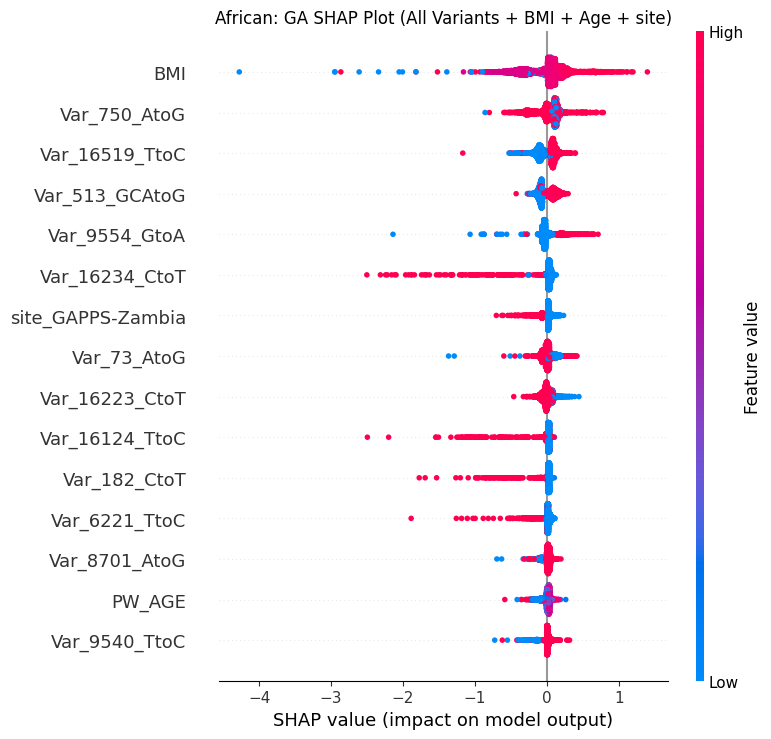

In [54]:
#GA SHAP visulaization
#Create SHAP explainer
explainer_af_ga = shap.TreeExplainer(rf_af_ga)
shap_values_af_ga = explainer_af_ga.shap_values(X_af_rf)

#Summary plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_af_ga, X_af_rf,
                  max_display=15,
                  show=False)
plt.title("African: GA SHAP Plot (All Variants + BMI + Age + site)")
plt.tight_layout()
plt.show()

In [55]:
 #BMI was the strongest predictor of gestational age, with mtDNA variants Var_750_AtoG and Var_16519_TtoC also showing notable contributions